<a href="https://colab.research.google.com/github/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/blob/main/Lecture-22-April-16-2026/Lecture-22_QM9-Dataset-Initial-Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lecture 22 - QM9 Dataset

The QM9 dataset:
- [MoleculeNet: a benchmark for molecular machine learning](https://pubs.rsc.org/en/content/articlelanding/2018/sc/c7sc02664a)
- [QM9 in  PyG (PyTorch Geometric)](https://pytorch-geometric.readthedocs.io/en/stable/generated/torch_geometric.datasets.QM9.html)
- [GNN-based molecular property prediction](https://projects.volkamerlab.org/teachopencadd/talktorials/T035_graph_neural_networks.html)


In [30]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install rdkit lightgbm mols2grid torch_geometric

Import all basic pacakges

In [31]:
# basic
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# RDkit
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

# For progress bar
from tqdm.auto import tqdm

# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

# LightGBM
from lightgbm import LGBMRegressor, plot_importance


tqdm.pandas()

Download dataset

In [33]:
%%bash
wget https://deepchemdata.s3.us-west-1.amazonaws.com/datasets/qm9.tar.gz
tar xvf qm9.tar.gz

qm9.sdf
qm9.sdf.csv


--2026-04-16 16:29:15--  https://deepchemdata.s3.us-west-1.amazonaws.com/datasets/qm9.tar.gz
Resolving deepchemdata.s3.us-west-1.amazonaws.com (deepchemdata.s3.us-west-1.amazonaws.com)... 16.15.0.53, 52.219.112.65, 52.219.117.1, ...
Connecting to deepchemdata.s3.us-west-1.amazonaws.com (deepchemdata.s3.us-west-1.amazonaws.com)|16.15.0.53|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53359625 (51M) [application/x-gzip]
Saving to: ‘qm9.tar.gz.1’

     0K .......... .......... .......... .......... ..........  0%  692K 75s
    50K .......... .......... .......... .......... ..........  0%  660K 77s
   100K .......... .......... .......... .......... ..........  0%  717K 75s
   150K .......... .......... .......... .......... ..........  0%  149M 57s
   200K .......... .......... .......... .......... ..........  0%  697K 60s
   250K .......... .......... .......... .......... ..........  0%  251M 50s
   300K .......... .......... .......... .......... .........

In [34]:
!ls

qm9.sdf  qm9.sdf.csv  qm9.tar.gz  qm9.tar.gz.1	sample_data


In [35]:
!head qm9.sdf

gdb 1	157.7118	157.70997	157.70699	0.	13.21	-0.3877	0.1171	0.5048	35.3641	0.044749	-40.47893	-40.476062	-40.475117	-40.498597	6.469
 OpenBabel06302521273D

  5  4  0  0  0  0  0  0  0  0999 V2000
   -0.0127    1.0858    0.0080 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0022   -0.0060    0.0020 H   0  0  0  0  0  0  0  0  0  0  0  0
    1.0117    1.4638    0.0003 H   0  0  0  0  0  0  0  0  0  0  0  0
   -0.5408    1.4475   -0.8766 H   0  0  0  0  0  0  0  0  0  0  0  0
   -0.5238    1.4379    0.9064 H   0  0  0  0  0  0  0  0  0  0  0  0
  1  5  1  0  0  0  0


dRead dataset

In [44]:
molecules = Chem.SDMolSupplier('qm9.sdf', removeHs=False,
                                   sanitize=False)
data = pd.read_csv("qm9.sdf.csv")



In [45]:
data

,mol_id,A,B,C,mu,alpha,homo,lumo,gap,r2,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
0,gdb_1,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,35.3641,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772
1,gdb_2,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,26.1563,0.034358,-56.525887,-56.523026,-56.522082,-56.544961,6.316,-276.861363,-278.620271,-280.399259,-259.338802
2,gdb_3,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,19.0002,0.021375,-76.404702,-76.401867,-76.400922,-76.422349,6.002,-213.087624,-213.974294,-215.159658,-201.407171
3,gdb_4,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,59.5248,0.026841,-77.308427,-77.305527,-77.304583,-77.327429,8.574,-385.501997,-387.237686,-389.016047,-365.800724
4,gdb_5,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,48.7476,0.016601,-93.411888,-93.409370,-93.408425,-93.431246,6.278,-301.820534,-302.906752,-304.091489,-288.720028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133880,gdb_133881,3.59483,2.198990,1.904230,1.6637,69.37,-0.2254,0.0588,0.2842,760.7472,0.127406,-400.633868,-400.628599,-400.627654,-400.663098,23.658,-1603.983913,-1614.898804,-1623.788097,-1492.819438
133881,gdb_133882,3.65648,2.142370,1.904390,1.2976,69.52,-0.2393,0.0608,0.3002,762.6354,0.127495,-400.629713,-400.624444,-400.623500,-400.658942,23.697,-1601.376613,-1612.291504,-1621.181424,-1490.211511
133882,gdb_133883,3.67118,2.143140,1.895010,1.2480,73.60,-0.2233,0.0720,0.2953,780.3553,0.140458,-380.753918,-380.748619,-380.747675,-380.783148,23.972,-1667.045429,-1678.830048,-1688.312964,-1549.143391
133883,gdb_133884,3.52845,2.151310,1.865820,1.9576,77.40,-0.2122,0.0881,0.3003,803.1904,0.152222,-364.720374,-364.714974,-364.714030,-364.749650,24.796,-1794.600439,-1807.210860,-1817.286772,-1670.349892


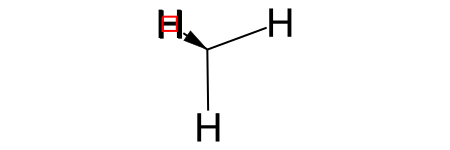

In [46]:
molecules[0]

In [47]:
molecules[100].GetProp('_Name')

'gdb 101\t7.36997\t4.78662\t3.53123\t1.3092\t45.84\t-0.2518\t0.0822\t0.334\t418.298\t0.113827\t-232.32907\t-232.323327\t-232.322383\t-232.357426\t20.702'

In [48]:
property_names = list(rdMolDescriptors.Properties.GetAvailableProperties())
property_getter = rdMolDescriptors.Properties(property_names)

In [54]:
test = np.array(3*[np.nan])
test

array([nan, nan, nan])

In [70]:
def mol2props(mol):
    if mol:
        props = np.array(property_getter.ComputeProperties(mol))
        if len(props) != len(property_names):
          props = np.array(len(property_names)*[np.nan])
    else:
      props = np.array(len(property_names)*[np.nan])
    return props

In [58]:
for i, mol in enumerate(tqdm(molecules)):
  if mol is None:
    print(f"Problem with molecule with index {i:d}")

  0%|          | 0/133885 [00:00<?, ?it/s]

[16:40:16] Both bonds on one end of an atropisomer are on the same side - atoms are: 2 1
[16:40:17] ERROR: Atom line too short: '  6  8  1  0  0  0  0' on line 830022
[16:40:17] ERROR: moving to the beginning of the next molecule
[16:40:17] ERROR: Atom line too short: '  7  8  2  0  0  0  0' on line 830032
[16:40:17] ERROR: moving to the beginning of the next molecule
[16:40:17] ERROR: Atom line too short: '  7  8  2  0  0  0  0' on line 830042
[16:40:17] ERROR: moving to the beginning of the next molecule
[16:40:17] ERROR: Atom line too short: '  7  2  1  0  0  0  0' on line 830052
[16:40:17] ERROR: moving to the beginning of the next molecule
[16:40:17] ERROR: Atom line too short: '  5  6  1  0  0  0  0' on line 830062
[16:40:17] ERROR: moving to the beginning of the next molecule
[16:40:17] ERROR: Atom line too short: '  6  7  1  0  0  0  0' on line 830072
[16:40:17] ERROR: moving to the beginning of the next molecule
[16:40:17] ERROR: Atom line too short: '  7  2  1  0  0  0  0' on

Problem with molecule with index 21437
Problem with molecule with index 21438
Problem with molecule with index 21439
Problem with molecule with index 21440
Problem with molecule with index 21441
Problem with molecule with index 21442
Problem with molecule with index 21443
Problem with molecule with index 21444
Problem with molecule with index 21445
Problem with molecule with index 21446
Problem with molecule with index 21447
Problem with molecule with index 21448
Problem with molecule with index 21449
Problem with molecule with index 21450
Problem with molecule with index 21451
Problem with molecule with index 21452
Problem with molecule with index 21453
Problem with molecule with index 21454
Problem with molecule with index 21455
Problem with molecule with index 21456
Problem with molecule with index 21457
Problem with molecule with index 21458
Problem with molecule with index 21459
Problem with molecule with index 21460
Problem with molecule with index 21461
Problem with molecule wit

[16:40:18] The 2 defining bonds for an atropisomer are co-planar - atoms are: 4 2
[16:40:20] ERROR: Atom line too short: ' 12  5  1  0  0  0  0' on line 2001141
[16:40:20] ERROR: moving to the beginning of the next molecule
[16:40:20] ERROR: Atom line too short: ' 13  5  1  0  0  0  0' on line 2001150
[16:40:20] ERROR: moving to the beginning of the next molecule
[16:40:20] ERROR: Atom line too short: ' 12  4  1  0  0  0  0' on line 2001159
[16:40:20] ERROR: moving to the beginning of the next molecule
[16:40:20] ERROR: Atom line too short: ' 12  4  1  0  0  0  0' on line 2001168
[16:40:20] ERROR: moving to the beginning of the next molecule
[16:40:20] ERROR: Atom line too short: ' 10  2  1  0  0  0  0' on line 2001177
[16:40:20] ERROR: moving to the beginning of the next molecule
[16:40:20] ERROR: Atom line too short: '  9  8  3  0  0  0  0' on line 2001186
[16:40:20] ERROR: moving to the beginning of the next molecule
[16:40:20] ERROR: Atom line too short: '  9  8  3  0  0  0  0' on 

Problem with molecule with index 50411
Problem with molecule with index 50412
Problem with molecule with index 50413
Problem with molecule with index 50414
Problem with molecule with index 50415
Problem with molecule with index 50416
Problem with molecule with index 50417
Problem with molecule with index 50418
Problem with molecule with index 50419
Problem with molecule with index 50420
Problem with molecule with index 50421
Problem with molecule with index 50422
Problem with molecule with index 50423
Problem with molecule with index 50424
Problem with molecule with index 50425
Problem with molecule with index 50426
Problem with molecule with index 50427
Problem with molecule with index 50428
Problem with molecule with index 50429
Problem with molecule with index 50430
Problem with molecule with index 50431
Problem with molecule with index 50432
Problem with molecule with index 50433
Problem with molecule with index 50434
Problem with molecule with index 50435
Problem with molecule wit

[16:40:22] The 2 defining bonds for an atropisomer are co-planar - atoms are: 4 5
[16:40:22] The 2 defining bonds for an atropisomer are co-planar - atoms are: 6 5
[16:40:22] The 2 defining bonds for an atropisomer are co-planar - atoms are: 1 3
[16:40:22] Both bonds on one end of an atropisomer are on the same side - atoms are: 1 8
[16:40:22] Both bonds on one end of an atropisomer are on the same side - atoms are: 1 8
[16:40:22] Both bonds on one end of an atropisomer are on the same side - atoms are: 1 8
[16:40:23] Both bonds on one end of an atropisomer are on the same side - atoms are: 7 1
[16:40:24] The 2 defining bonds for an atropisomer are co-planar - atoms are: 4 6
[16:40:27] ERROR: Atom line too short: ' 11  1  1  0  0  0  0' on line 4873308
[16:40:27] ERROR: moving to the beginning of the next molecule
[16:40:27] ERROR: Atom line too short: '  7  6  1  0  0  0  0' on line 4873318
[16:40:27] ERROR: moving to the beginning of the next molecule
[16:40:27] ERROR: Atom line too 

Problem with molecule with index 114155
Problem with molecule with index 114156
Problem with molecule with index 114157
Problem with molecule with index 114158
Problem with molecule with index 114159
Problem with molecule with index 114160
Problem with molecule with index 114161
Problem with molecule with index 114162
Problem with molecule with index 114163
Problem with molecule with index 114164
Problem with molecule with index 114165
Problem with molecule with index 114166
Problem with molecule with index 114167
Problem with molecule with index 114168
Problem with molecule with index 114169
Problem with molecule with index 114170
Problem with molecule with index 114171
Problem with molecule with index 114172
Problem with molecule with index 114173
Problem with molecule with index 114174
Problem with molecule with index 114175
Problem with molecule with index 114176
Problem with molecule with index 114177
Problem with molecule with index 114178
Problem with molecule with index 114179


[16:40:29] The 2 defining bonds for an atropisomer are co-planar - atoms are: 2 7


In [57]:
props = []
for i, mol in enumerate(tqdm(molecules)):
  prop = mol2props(mol)
  props.append(prop)

  0%|          | 0/133885 [00:00<?, ?it/s]

[16:36:01] Both bonds on one end of an atropisomer are on the same side - atoms are: 2 1
[16:36:30] ERROR: Atom line too short: '  6  8  1  0  0  0  0' on line 830022
[16:36:30] ERROR: moving to the beginning of the next molecule
[16:36:30] ERROR: Atom line too short: '  7  8  2  0  0  0  0' on line 830032
[16:36:30] ERROR: moving to the beginning of the next molecule
[16:36:30] ERROR: Atom line too short: '  7  8  2  0  0  0  0' on line 830042
[16:36:30] ERROR: moving to the beginning of the next molecule
[16:36:30] ERROR: Atom line too short: '  7  2  1  0  0  0  0' on line 830052
[16:36:30] ERROR: moving to the beginning of the next molecule
[16:36:30] ERROR: Atom line too short: '  5  6  1  0  0  0  0' on line 830062
[16:36:30] ERROR: moving to the beginning of the next molecule
[16:36:30] ERROR: Atom line too short: '  6  7  1  0  0  0  0' on line 830072
[16:36:30] ERROR: moving to the beginning of the next molecule
[16:36:30] ERROR: Atom line too short: '  7  2  1  0  0  0  0' on

In [64]:
indices = [i for i, x in enumerate(props) if x is None]
print(indices)
for idx in indices:
  props[idx] = np.array(len(property_names)*[np.nan])

[]


In [67]:
data[property_names]=props

In [68]:
data

,mol_id,A,B,C,mu,alpha,homo,lumo,gap,r2,...,chi0n,chi1n,chi2n,chi3n,chi4n,hallKierAlpha,kappa1,kappa2,kappa3,Phi
0,gdb_1,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,35.3641,...,4.500000,2.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000
1,gdb_2,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,26.1563,...,3.447214,1.341641,0.000000,0.000000,0.000000,-0.04,0.000175,-27.040000,-104.040000,-0.004740
2,gdb_3,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,19.0002,...,2.408248,0.816497,0.000000,0.000000,0.000000,-0.04,0.000400,-27.040000,-104.040000,-0.010811
3,gdb_4,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,59.5248,...,3.000000,1.250000,0.000000,0.000000,0.000000,0.00,0.222222,0.000000,0.000000,0.000000
4,gdb_5,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,48.7476,...,1.947214,0.723607,0.000000,0.000000,0.000000,-0.04,0.470204,0.960000,-27.040000,0.225698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133880,gdb_133881,3.59483,2.198990,1.904230,1.6637,69.37,-0.2254,0.0588,0.2842,760.7472,...,11.355462,6.579069,2.759194,2.759194,2.334089,-0.08,1.410057,0.564504,0.120875,0.088443
133881,gdb_133882,3.65648,2.142370,1.904390,1.2976,69.52,-0.2393,0.0608,0.3002,762.6354,...,11.355462,6.579069,2.777778,2.777778,2.349374,-0.08,1.410057,0.564504,0.120875,0.088443
133882,gdb_133883,3.67118,2.143140,1.895010,1.2480,73.60,-0.2233,0.0720,0.2953,780.3553,...,12.394427,7.091641,2.786765,2.786765,2.364203,-0.08,1.278474,0.564504,0.120875,0.080189
133883,gdb_133884,3.52845,2.151310,1.865820,1.9576,77.40,-0.2122,0.0881,0.3003,803.1904,...,13.447214,7.670820,2.910739,2.910739,2.504489,-0.04,1.177252,0.572166,0.122927,0.074843


In [71]:
print("Size before:", len(data))
data = data.dropna()
print("Size after:", len(data))

Size before: 133763
Size after: 133763


## Visualize Target Values

A
- 9.81921510
- 3.08994000
- 1810.28388051


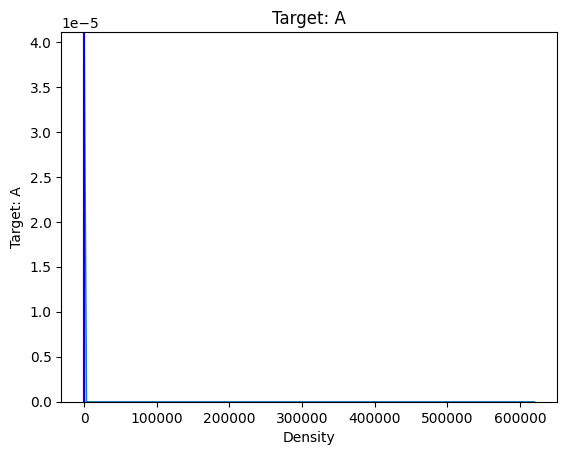

B
- 1.40609932
- 1.36989000
- 1.58446869


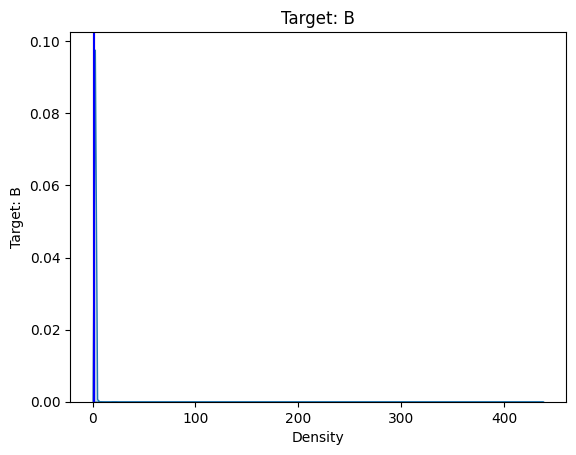

C
- 1.12497401
- 1.07856000
- 1.09610031


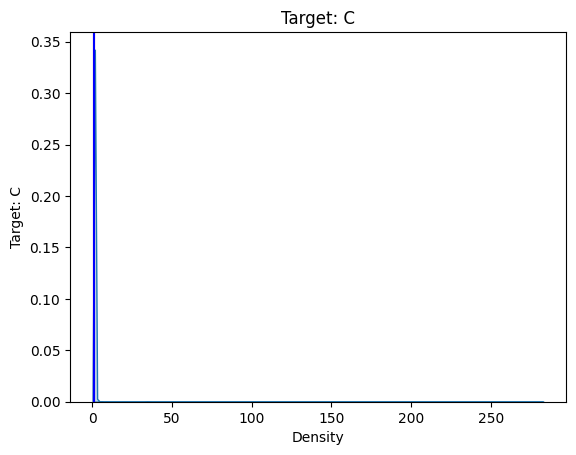

mu
- 2.70546817
- 2.49920000
- 1.53028495


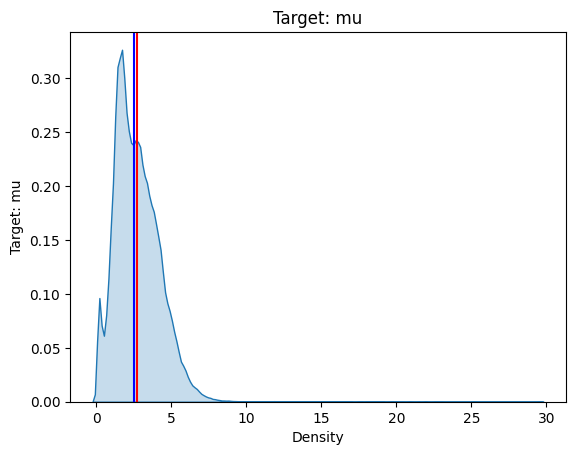

alpha
- 75.19678992
- 75.50000000
- 8.18461982


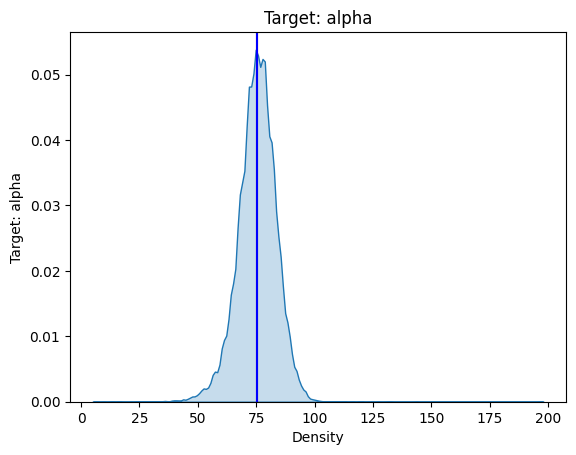

homo
- -0.23997070
- -0.24100000
- 0.02213205


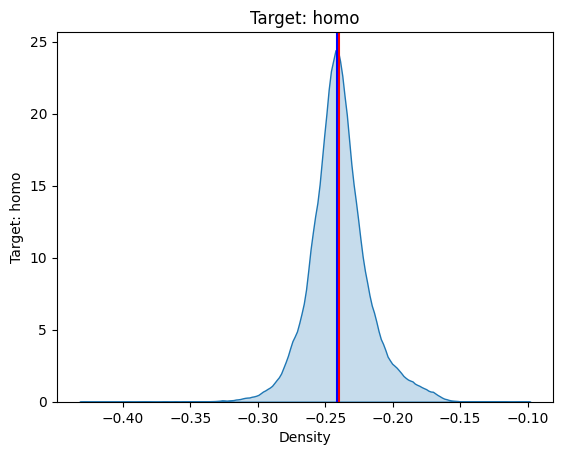

lumo
- 0.01115893
- 0.01200000
- 0.04693505


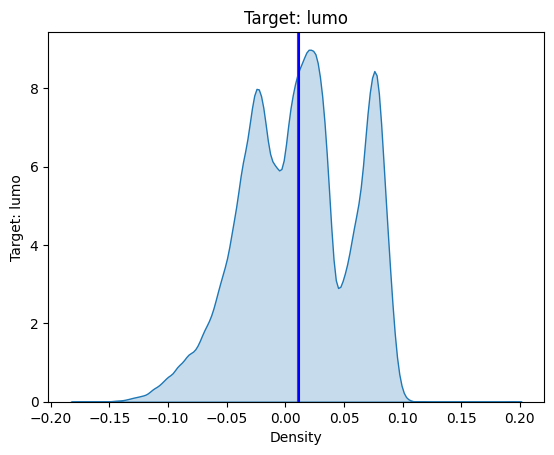

gap
- 0.25112953
- 0.24950000
- 0.04752577


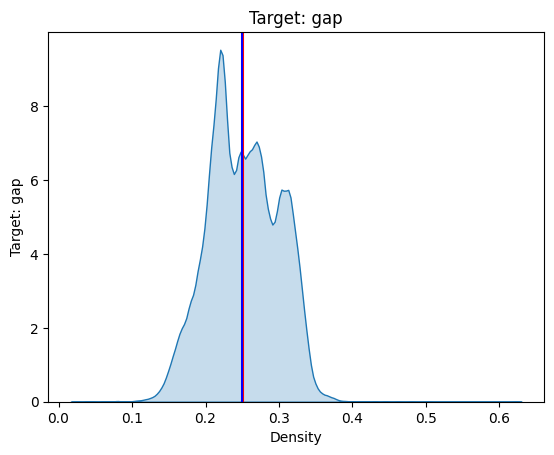

r2
- 1189.61121596
- 1147.63330000
- 279.81058517


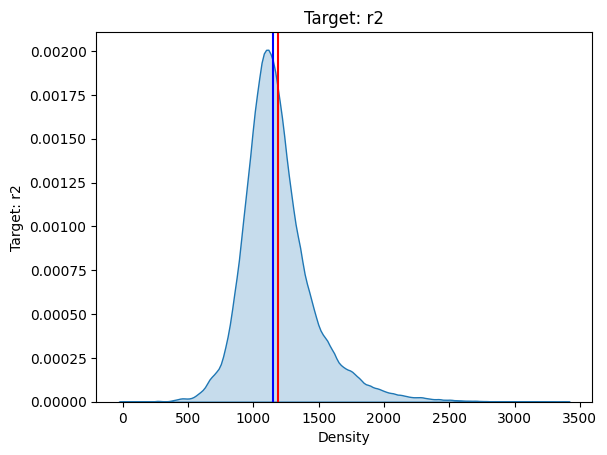

zpve
- 0.14855359
- 0.14834100
- 0.03326048


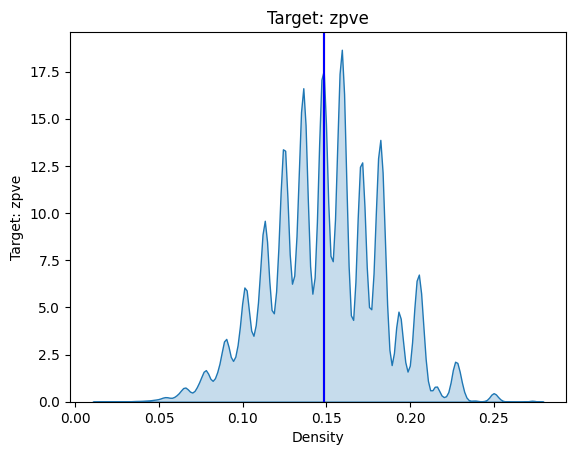

u0
- -411.53759022
- -417.86378700
- 40.07205251


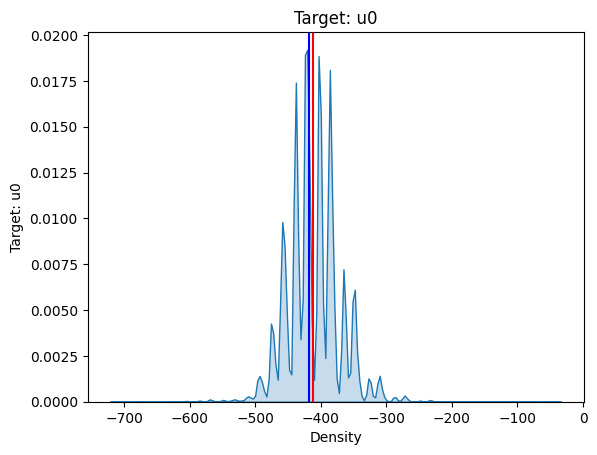

u298
- -411.52911824
- -417.85620200
- 40.07183337


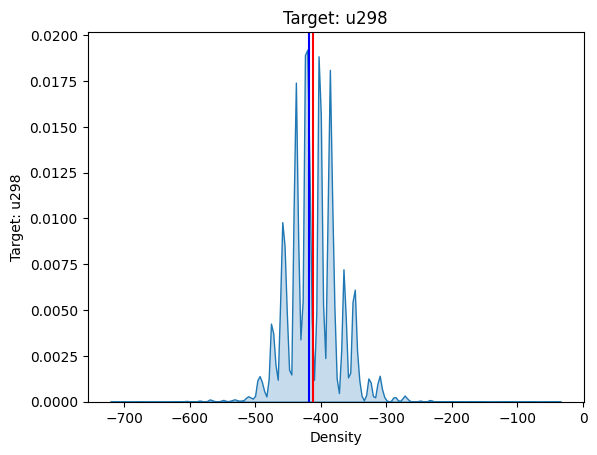

h298
- -411.52817405
- -417.85525800
- 40.07183337


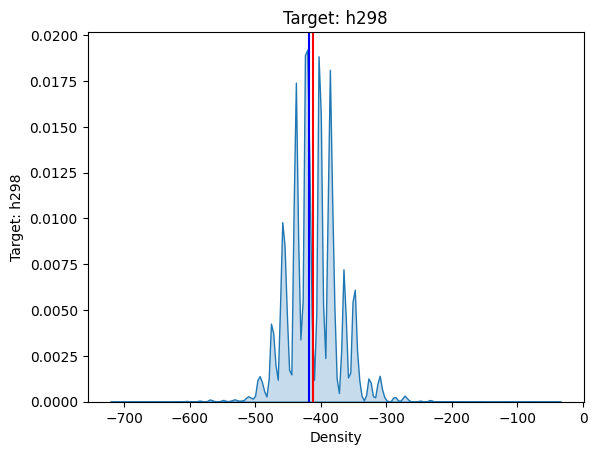

g298
- -411.57100334
- -417.89553200
- 40.07256316


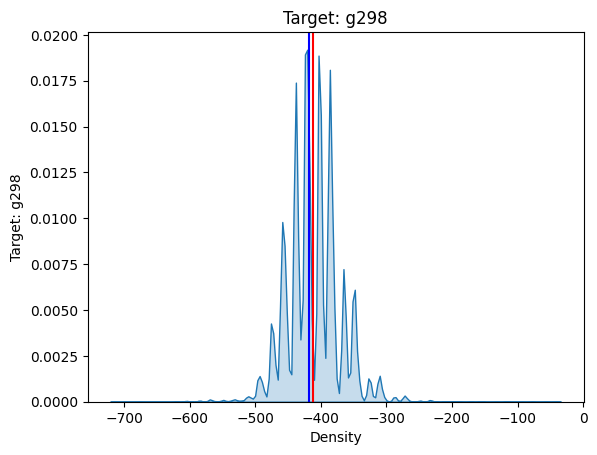

cv
- 31.60393844
- 31.55700000
- 4.06117211


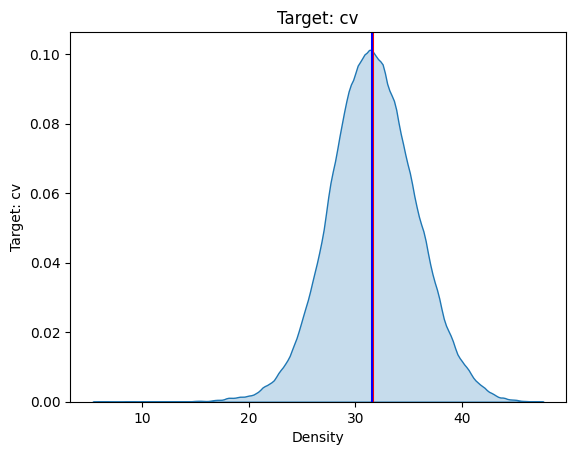

u0_atom
- -1751.04043473
- -1753.59900086
- 239.13628798


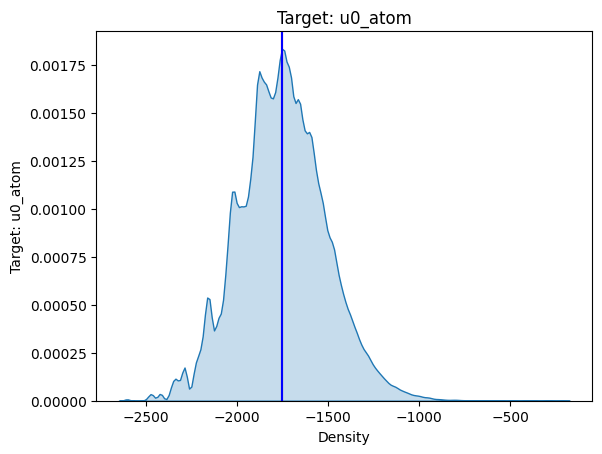

u298_atom
- -1761.71001087
- -1764.26288881
- 241.25809718


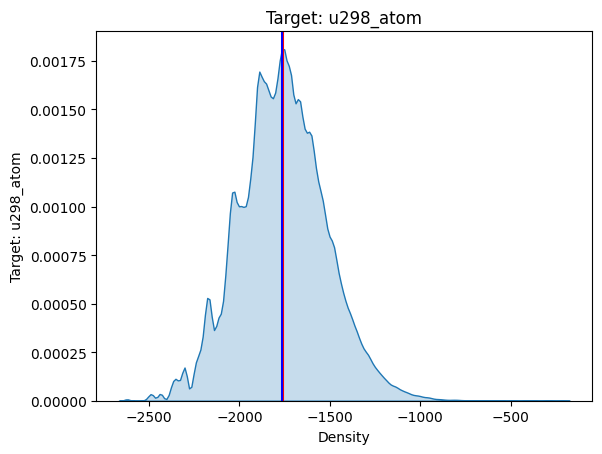

h298_atom
- -1771.77786114
- -1774.31558299
- 242.97222829


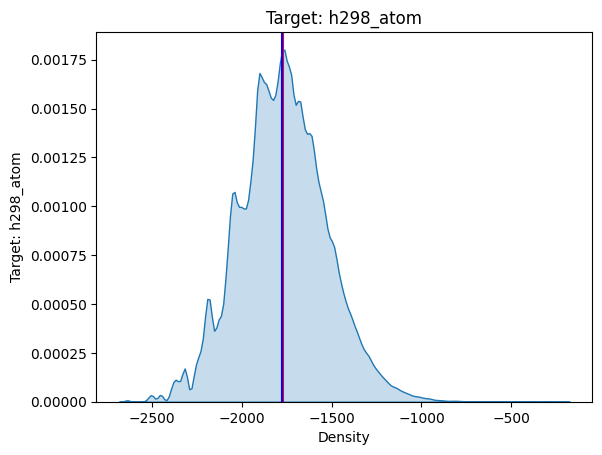

g298_atom
- -1629.59811101
- -1632.40442264
- 220.03958849


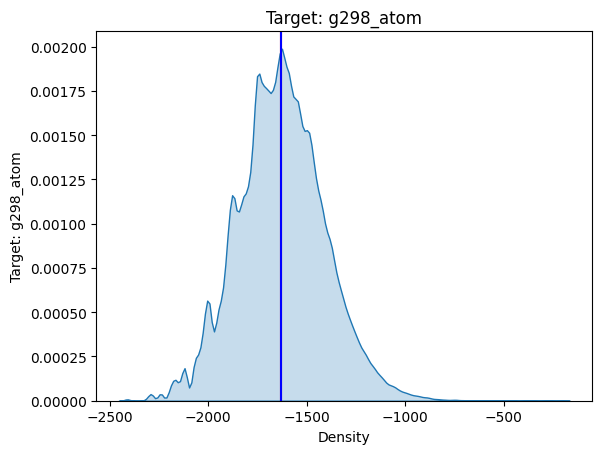

In [75]:
for t in targets:
  # print(t)
  mean = np.mean(data[t])
  median = np.median(data[t])
  stddev = np.std(data[t])
  print(f"{t:s}")
  print(f"- {mean:.8f}")
  print(f"- {median:.8f}")
  print(f"- {stddev:.8f}")
  sns.kdeplot(data[t],bw_adjust=0.6, fill=True, label=t)
  plt.axvline(mean, color="red")
  plt.axvline(median, color="blue")
  plt.title(f"Target: {t:s}")
  plt.xlabel("Density")
  plt.ylabel(f"Target: {t:s}")
  plt.show()

exactmw
- 122.68654200
- 125.04767846
- 7.56284070


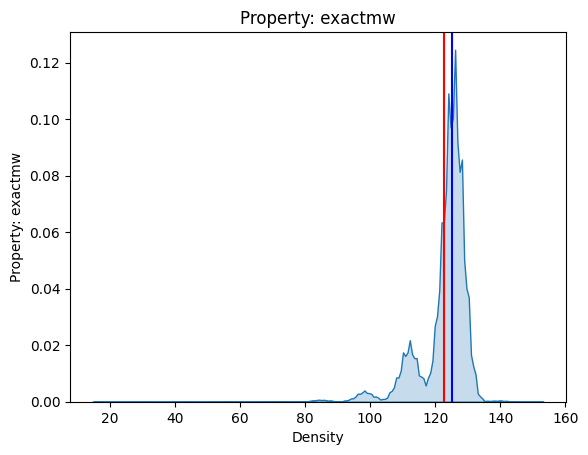

amw
- 122.76753699
- 125.12700000
- 7.56582851


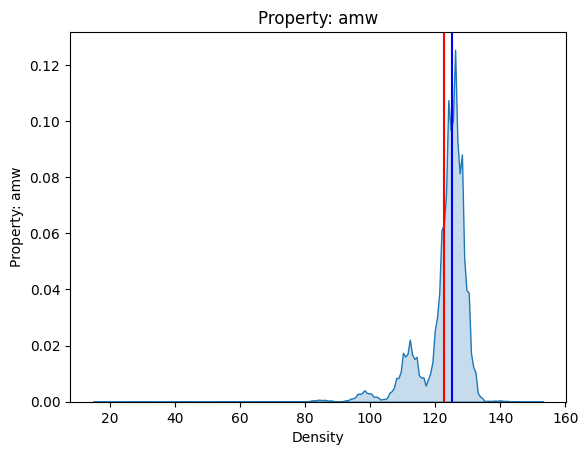

lipinskiHBA
- 2.44707430
- 2.00000000
- 1.16875940


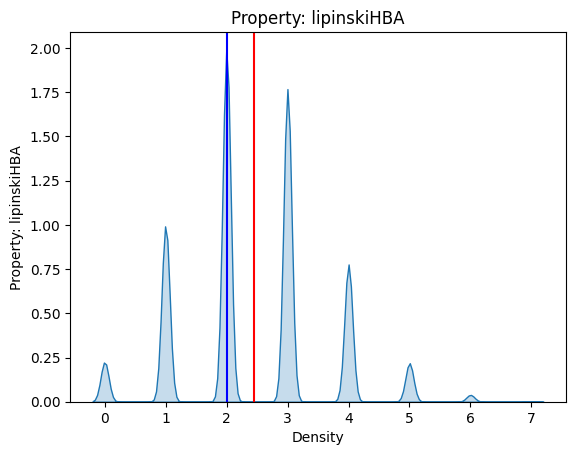

lipinskiHBD
- 0.93943766
- 1.00000000
- 1.02056186


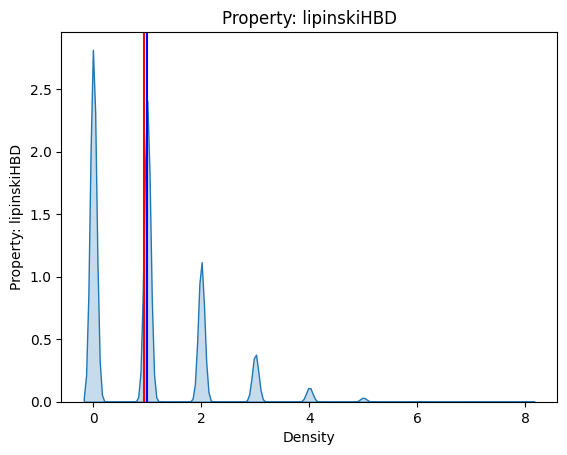

NumRotatableBonds
- 1.29156792
- 1.00000000
- 1.27467478


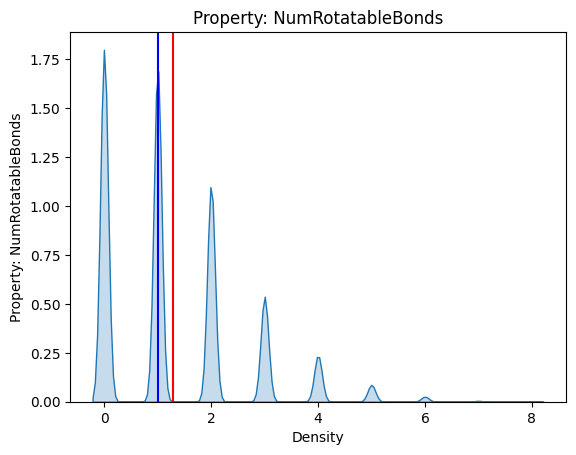

NumHBD
- 0.81521048
- 1.00000000
- 0.83444232


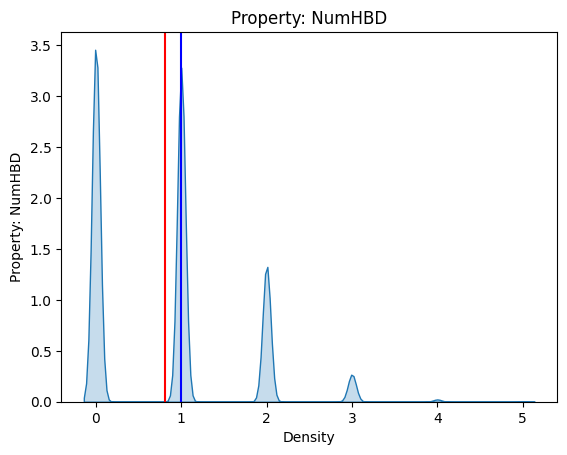

NumHBA
- 2.23475849
- 2.00000000
- 1.03808632


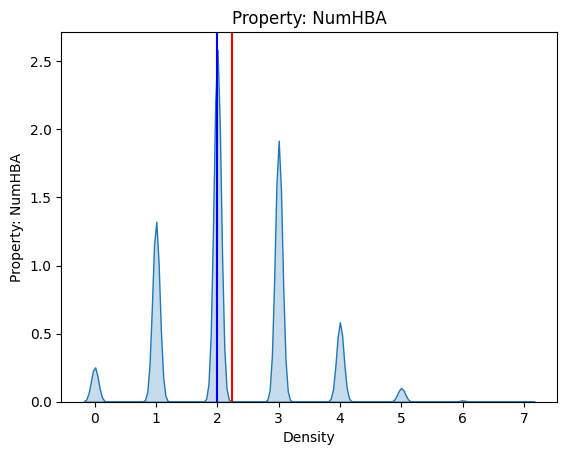

NumHeavyAtoms
- 8.79602730
- 9.00000000
- 0.50895121


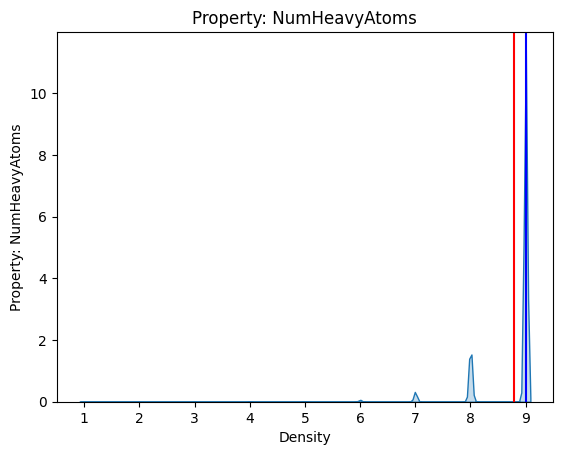

NumAtoms
- 17.98638637
- 18.00000000
- 2.95286442


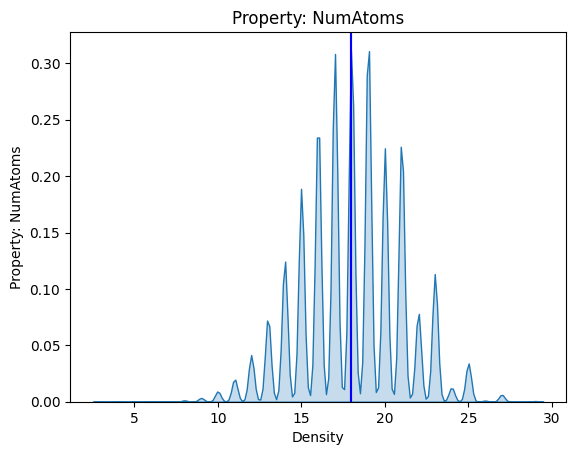

NumHeteroatoms
- 2.47184947
- 2.00000000
- 1.18403878


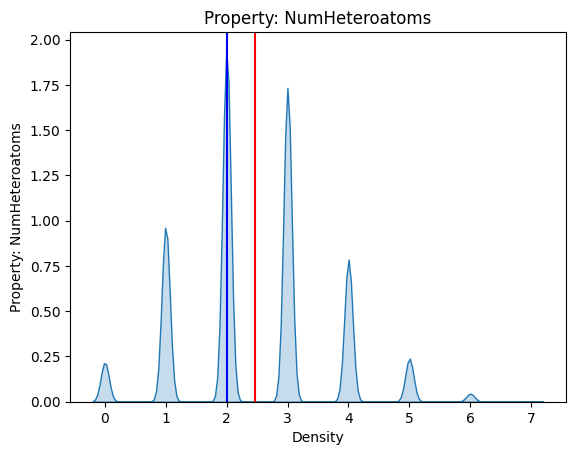

NumAmideBonds
- 0.14484573
- 0.00000000
- 0.41497551


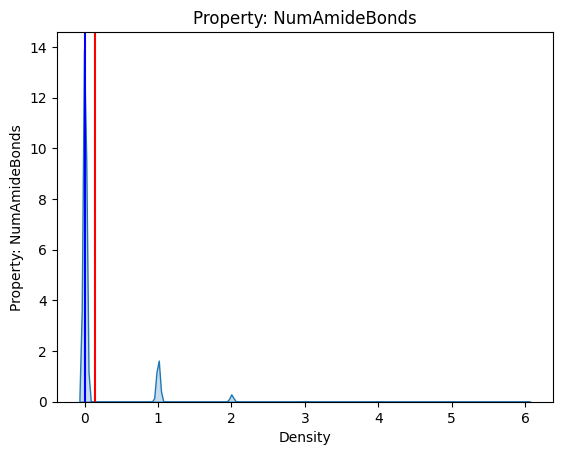

FractionCSP3
- 0.68758395
- 0.75000000
- 0.27938011


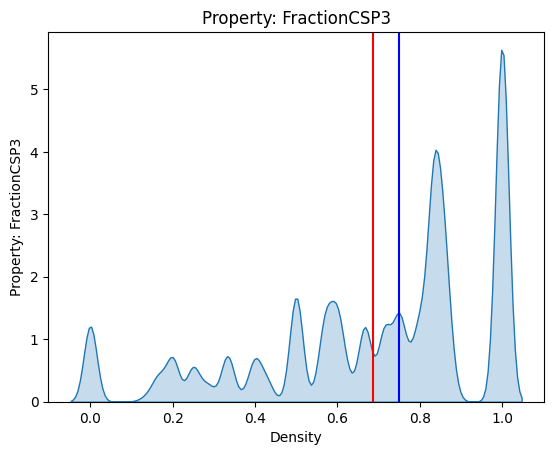

NumRings
- 1.73469495
- 1.00000000
- 1.20321698


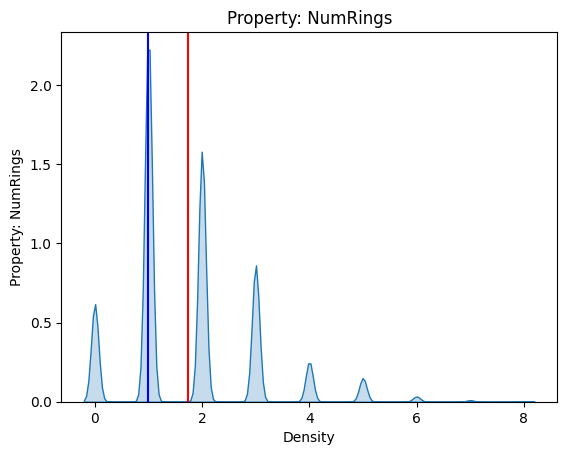

NumAromaticRings
- 0.00000000
- 0.00000000
- 0.00000000


/tmp/ipykernel_1602/2757959370.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data[t],bw_adjust=0.6, fill=True, label=t)


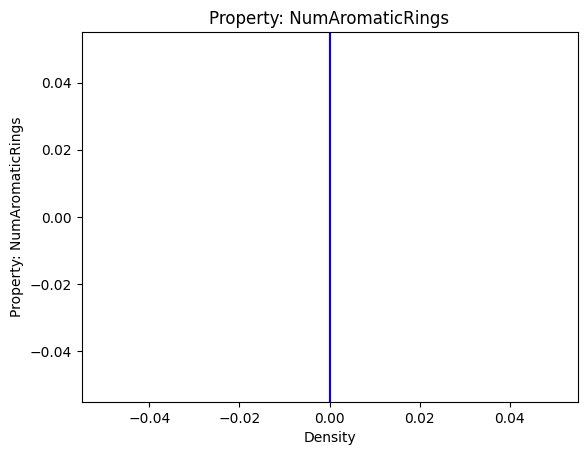

NumAliphaticRings
- 1.73469495
- 1.00000000
- 1.20321698


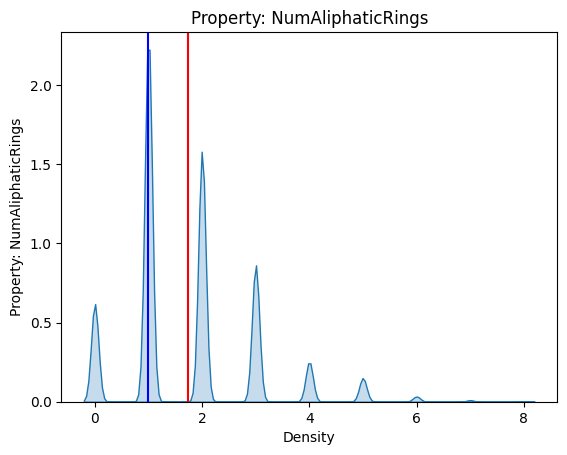

NumSaturatedRings
- 1.38563728
- 1.00000000
- 1.34650178


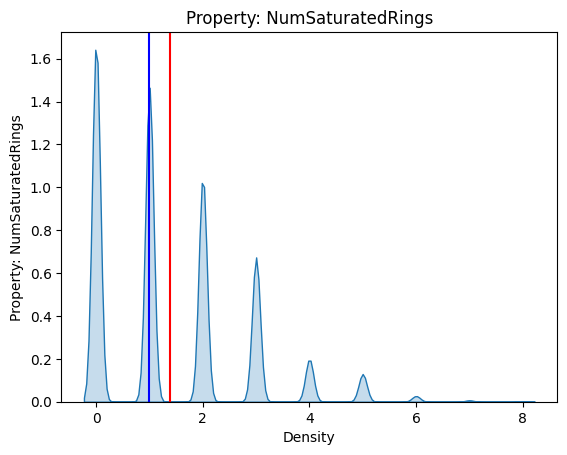

NumHeterocycles
- 1.00867953
- 1.00000000
- 0.89172556


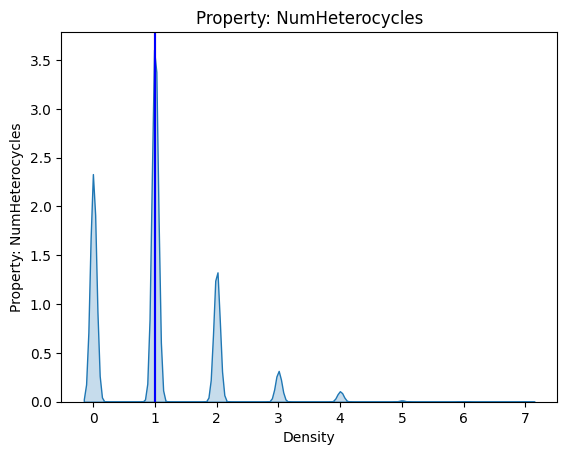

NumAromaticHeterocycles
- 0.00000000
- 0.00000000
- 0.00000000


/tmp/ipykernel_1602/2757959370.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data[t],bw_adjust=0.6, fill=True, label=t)


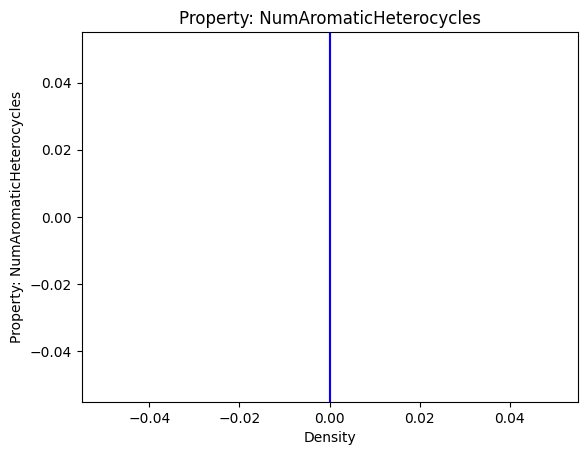

NumSaturatedHeterocycles
- 0.74601347
- 0.00000000
- 0.93241425


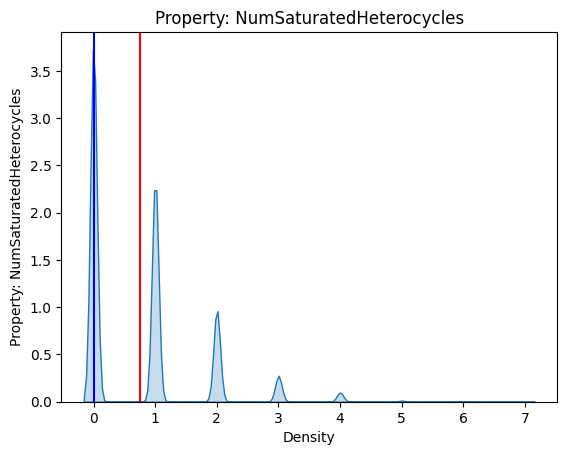

NumAliphaticHeterocycles
- 1.00867953
- 1.00000000
- 0.89172556


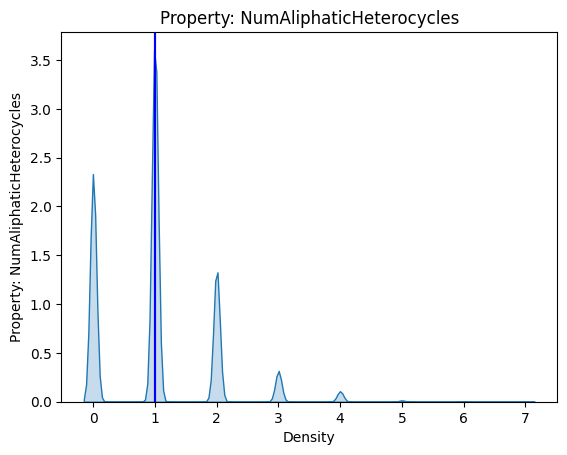

NumSpiroAtoms
- 0.08136779
- 0.00000000
- 0.28394214


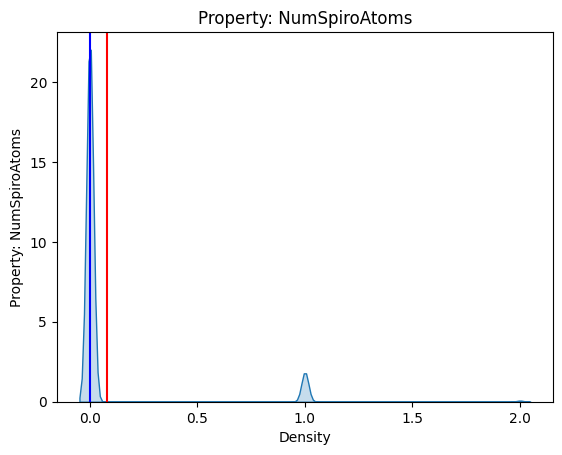

NumBridgeheadAtoms
- 0.31846624
- 0.00000000
- 0.93144999


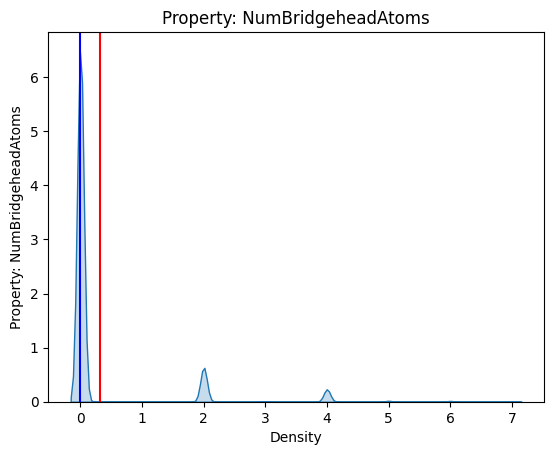

NumAtomStereoCenters
- 1.71352317
- 2.00000000
- 1.54160570


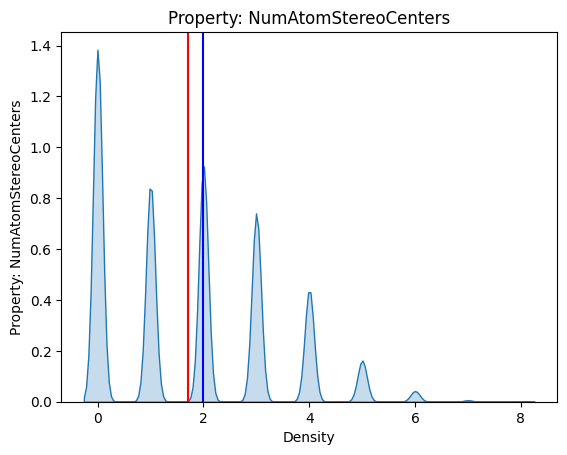

NumUnspecifiedAtomStereoCenters
- 0.00137557
- 0.00000000
- 0.03766338


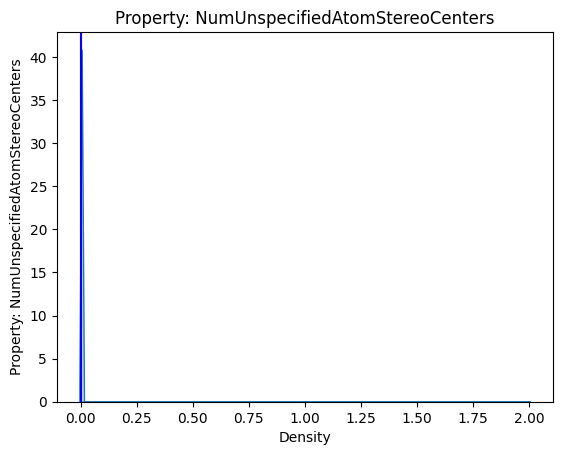

labuteASA
- 65.82338838
- 66.19105128
- 6.41258600


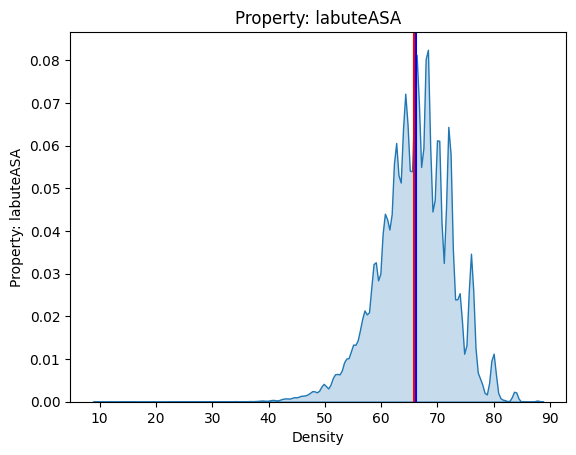

tpsa
- 36.48125259
- 35.53000000
- 20.65550492


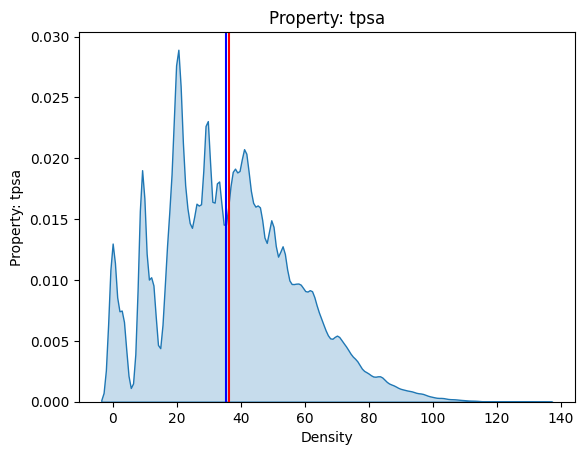

CrippenClogP
- 0.30344385
- 0.26397000
- 0.95565363


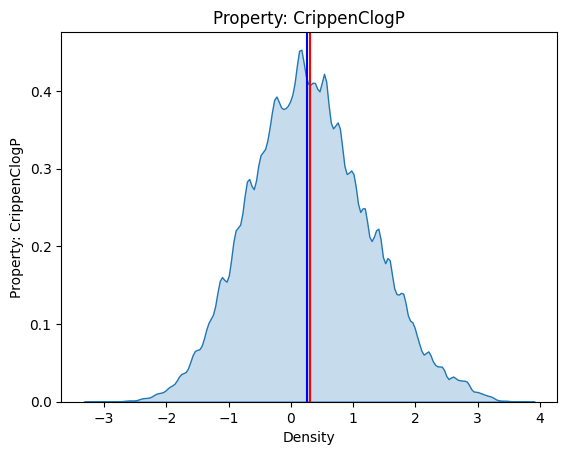

CrippenMR
- 32.26634694
- 32.42800000
- 3.39986065


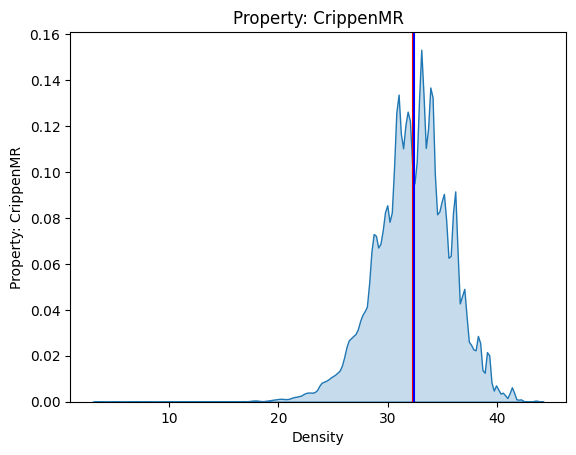

chi0v
- 4.21110403
- 4.30267548
- 0.26110756


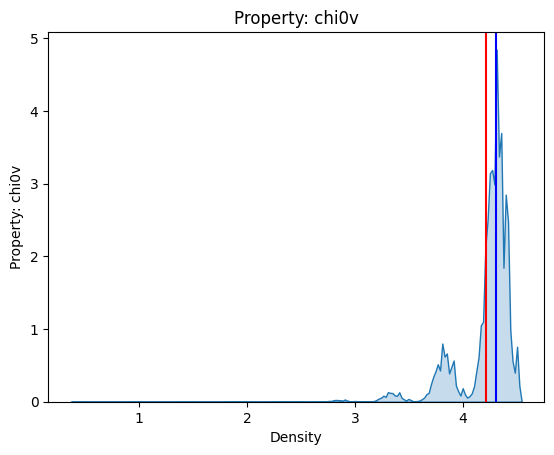

chi1v
- 2.20506551
- 2.15824829
- 0.30505582


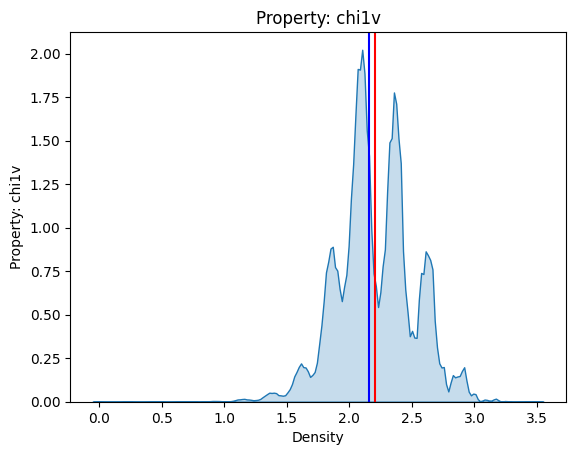

chi2v
- 1.04119407
- 0.93118622
- 0.50684369


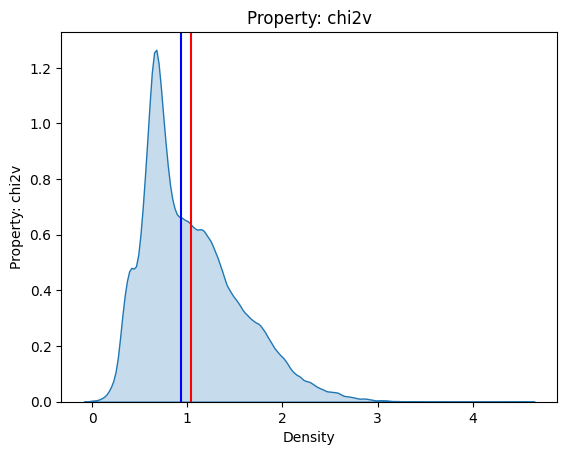

chi3v
- 1.04119407
- 0.93118622
- 0.50684369


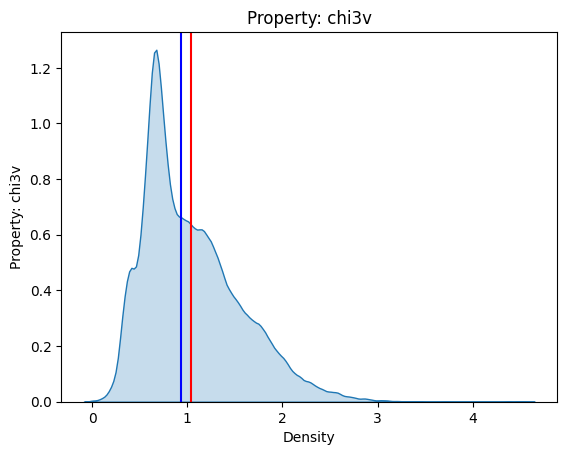

chi4v
- 0.59628529
- 0.45682637
- 0.41041792


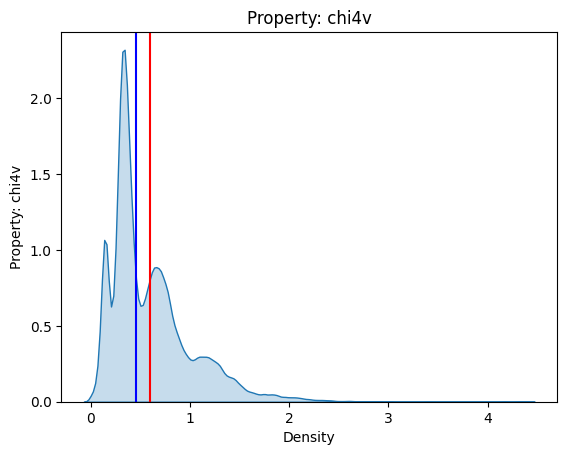

chi0n
- 13.40146310
- 13.35546189
- 2.92982710


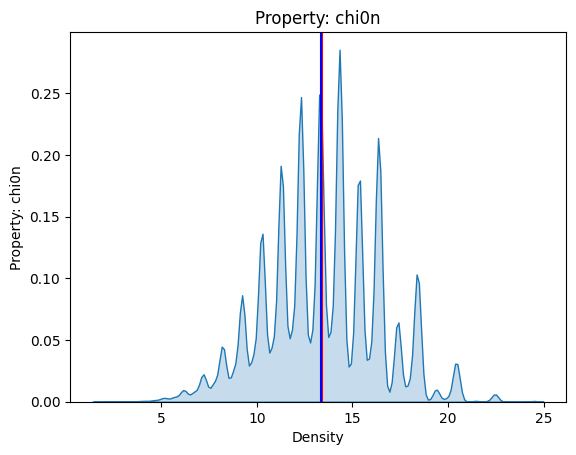

chi1n
- 6.73490234
- 6.76371018
- 1.52320186


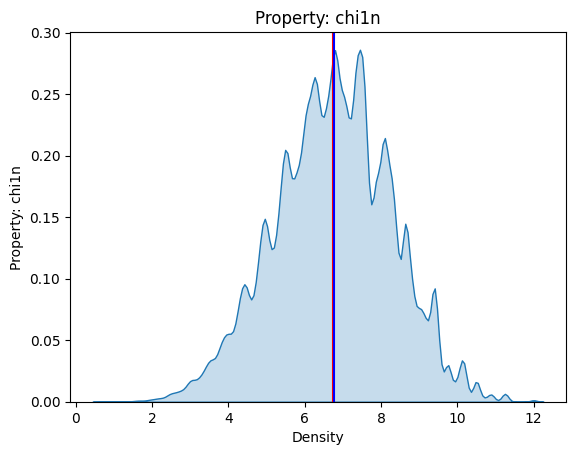

chi2n
- 1.04119407
- 0.93118622
- 0.50684369


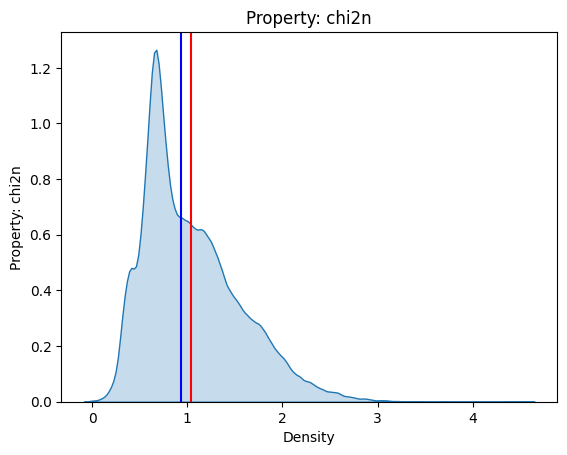

chi3n
- 1.04119407
- 0.93118622
- 0.50684369


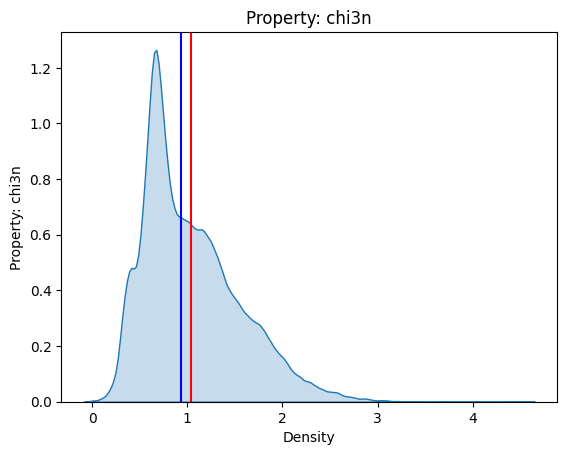

chi4n
- 0.59628529
- 0.45682637
- 0.41041792


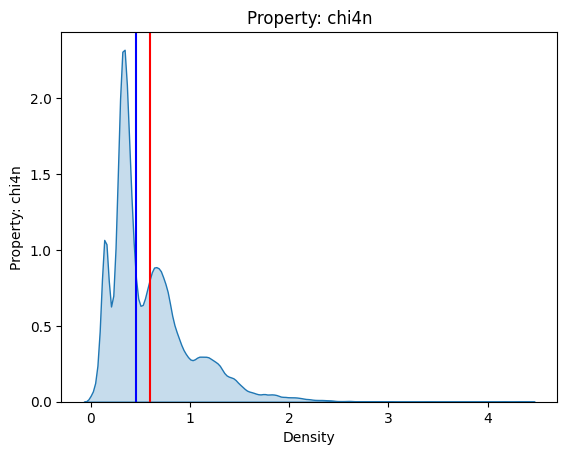

hallKierAlpha
- -0.11780440
- -0.08000000
- 0.14531746


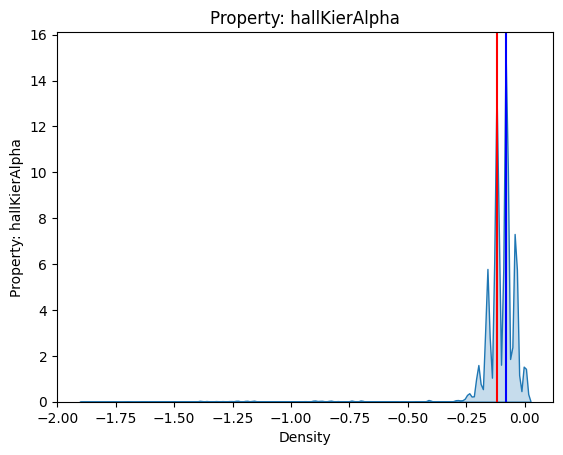

kappa1
- 1.63317371
- 1.53081459
- 0.62614782


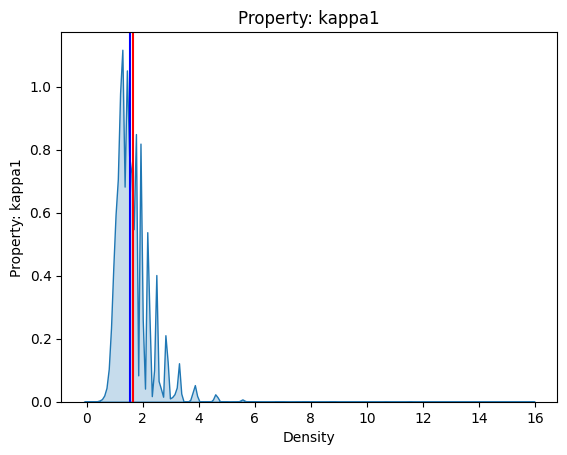

kappa2
- 2.25485471
- 1.95730678
- 1.87289958


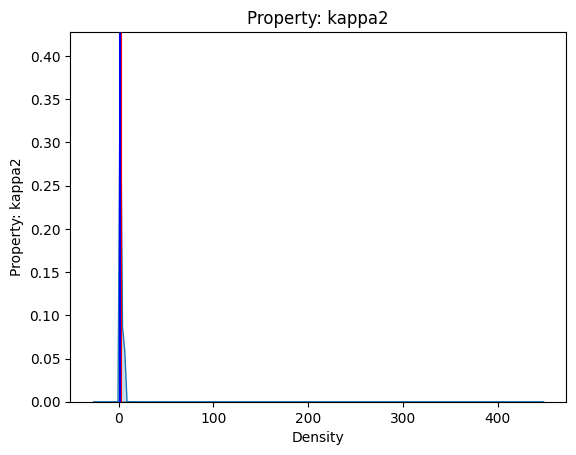

kappa3
- 3.50021401
- 0.92967687
- 503.34611953


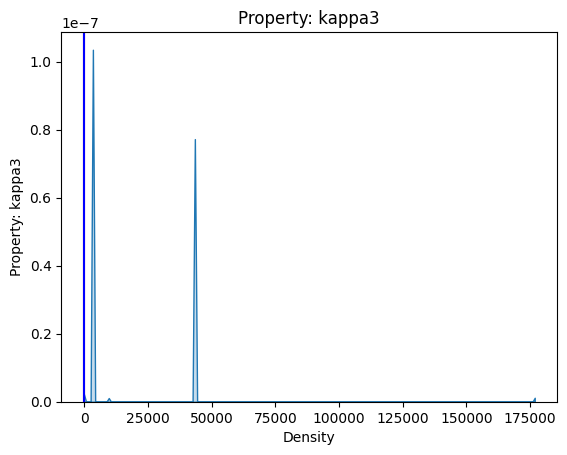

Phi
- 0.44995658
- 0.33025157
- 0.62287873


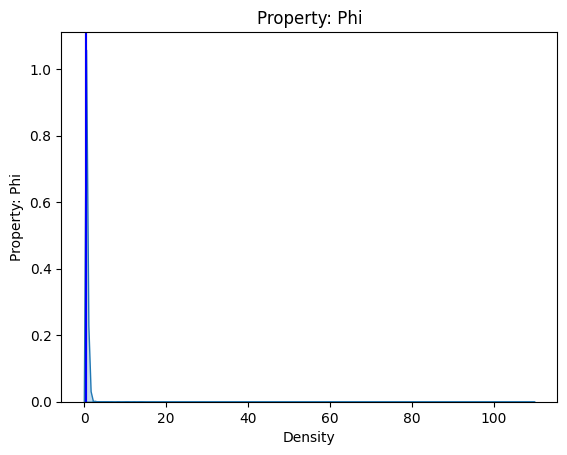

In [76]:
for t in property_names:
  # print(t)
  mean = np.mean(data[t])
  median = np.median(data[t])
  stddev = np.std(data[t])
  print(f"{t:s}")
  print(f"- {mean:.8f}")
  print(f"- {median:.8f}")
  print(f"- {stddev:.8f}")
  sns.kdeplot(data[t],bw_adjust=0.6, fill=True, label=t)
  plt.axvline(mean, color="red")
  plt.axvline(median, color="blue")
  plt.title(f"Property: {t:s}")
  plt.xlabel("Density")
  plt.ylabel(f"Property: {t:s}")
  plt.show()

## Train using LightGBM

In [77]:
train, test = train_test_split(data,test_size=0.20)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019204 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5152
[LightGBM] [Info] Number of data points in the train set: 107010, number of used features: 41
[LightGBM] [Info] Start training from score 11.405717


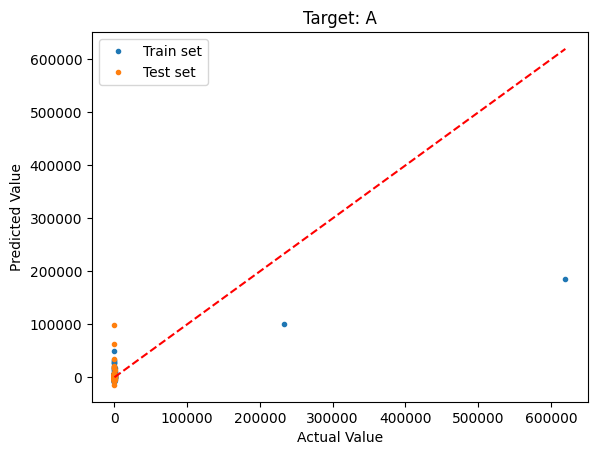

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5152
[LightGBM] [Info] Number of data points in the train set: 107010, number of used features: 41
[LightGBM] [Info] Start training from score 1.408665


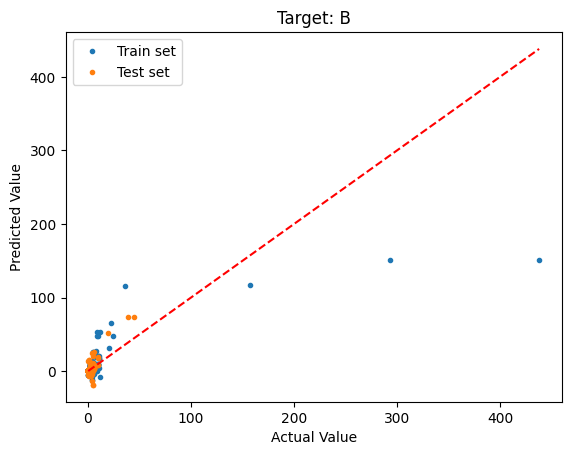

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018576 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5152
[LightGBM] [Info] Number of data points in the train set: 107010, number of used features: 41
[LightGBM] [Info] Start training from score 1.126638


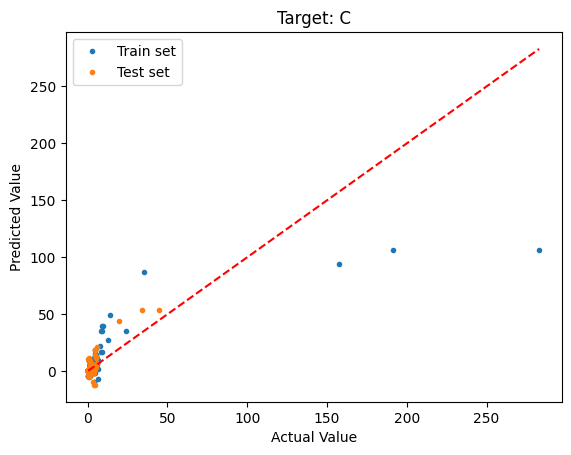

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019902 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5152
[LightGBM] [Info] Number of data points in the train set: 107010, number of used features: 41
[LightGBM] [Info] Start training from score 2.703875


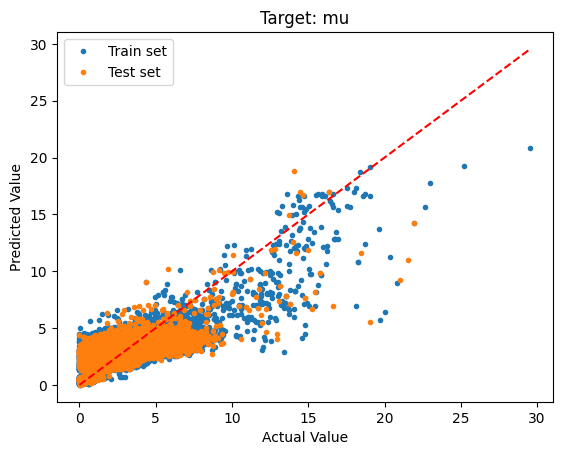

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019072 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5152
[LightGBM] [Info] Number of data points in the train set: 107010, number of used features: 41
[LightGBM] [Info] Start training from score 75.205177


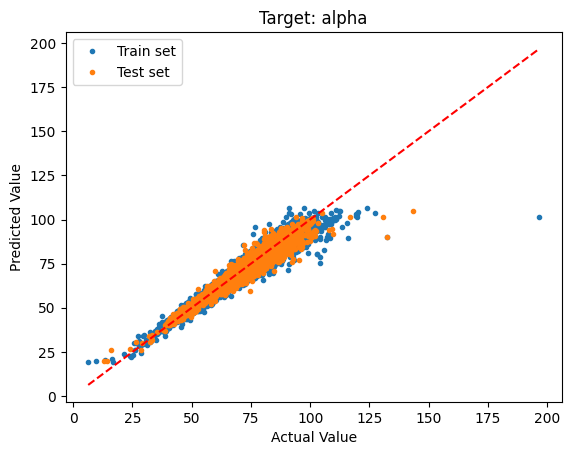

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033659 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5152
[LightGBM] [Info] Number of data points in the train set: 107010, number of used features: 41
[LightGBM] [Info] Start training from score -0.239965


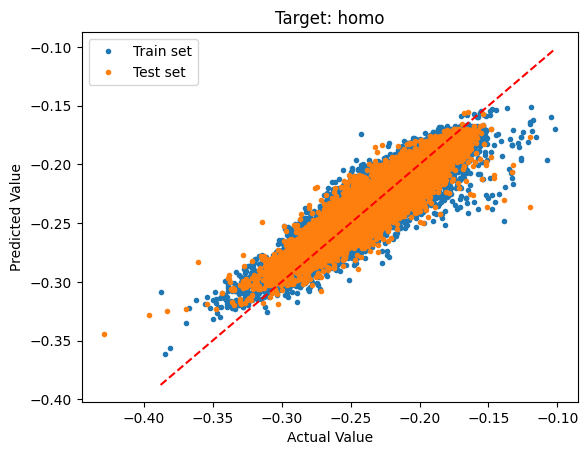

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018700 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5152
[LightGBM] [Info] Number of data points in the train set: 107010, number of used features: 41
[LightGBM] [Info] Start training from score 0.011302


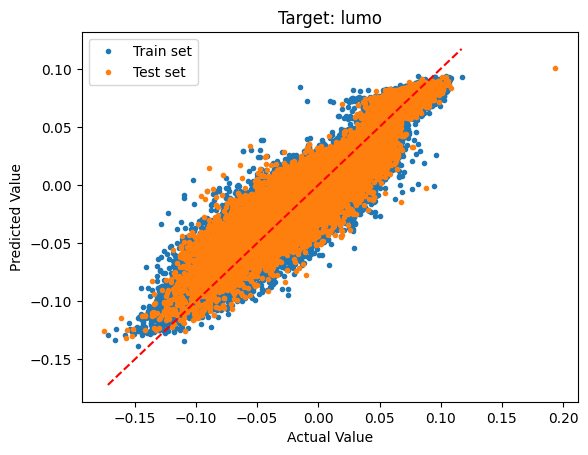

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021658 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5152
[LightGBM] [Info] Number of data points in the train set: 107010, number of used features: 41
[LightGBM] [Info] Start training from score 0.251267


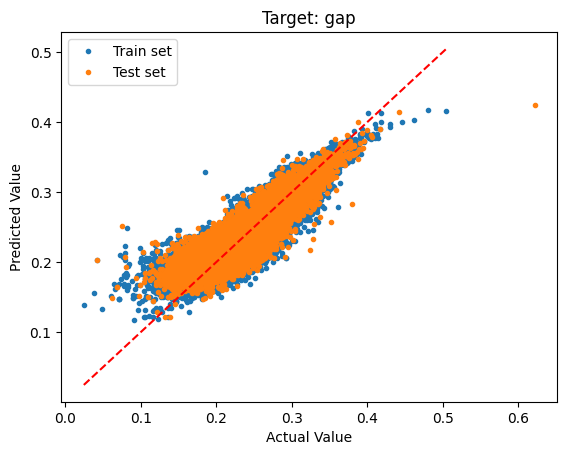

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018865 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5152
[LightGBM] [Info] Number of data points in the train set: 107010, number of used features: 41
[LightGBM] [Info] Start training from score 1189.097281


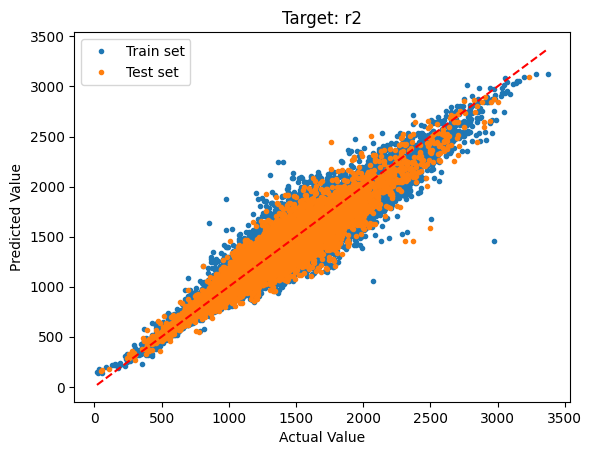

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018103 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5152
[LightGBM] [Info] Number of data points in the train set: 107010, number of used features: 41
[LightGBM] [Info] Start training from score 0.148577


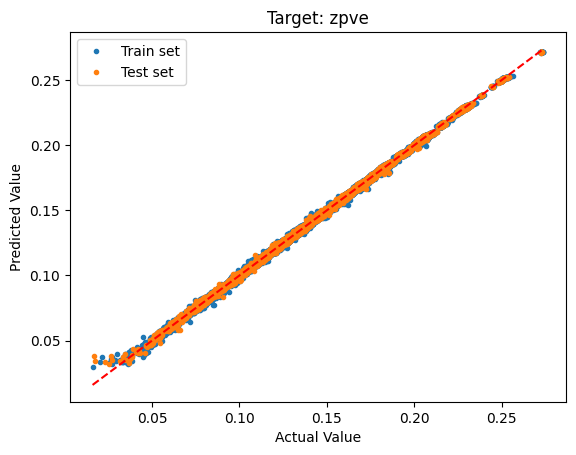

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019617 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5152
[LightGBM] [Info] Number of data points in the train set: 107010, number of used features: 41
[LightGBM] [Info] Start training from score -411.503869


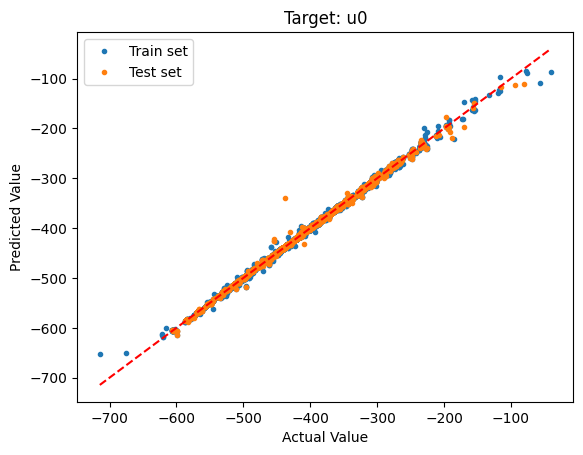

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018610 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5152
[LightGBM] [Info] Number of data points in the train set: 107010, number of used features: 41
[LightGBM] [Info] Start training from score -411.495400


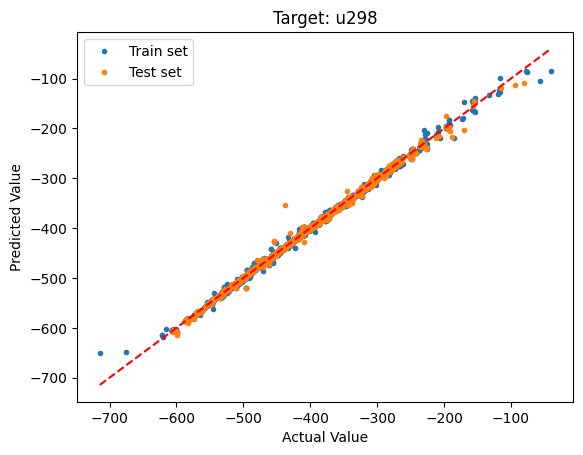

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.102285 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5152
[LightGBM] [Info] Number of data points in the train set: 107010, number of used features: 41
[LightGBM] [Info] Start training from score -411.494456


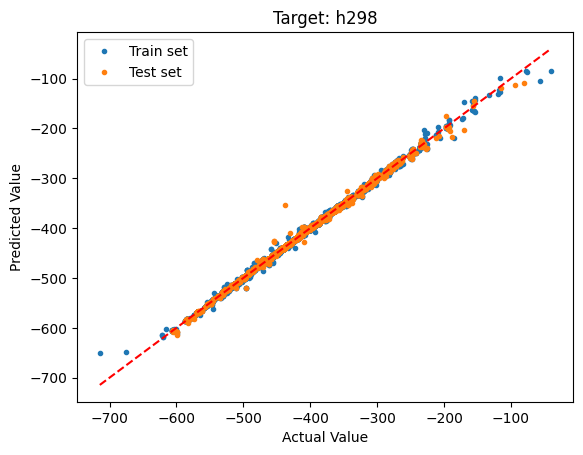

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020039 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5152
[LightGBM] [Info] Number of data points in the train set: 107010, number of used features: 41
[LightGBM] [Info] Start training from score -411.537278


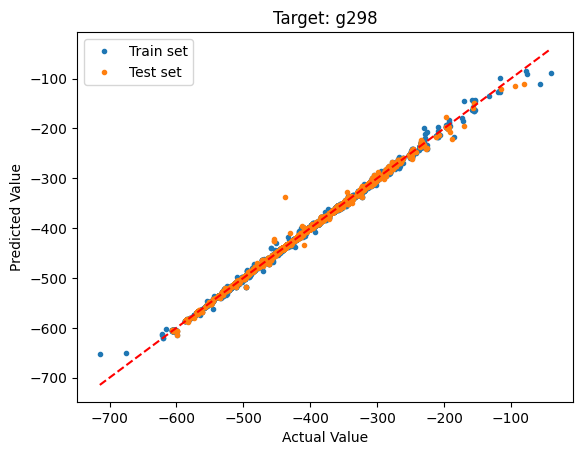

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.065691 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5152
[LightGBM] [Info] Number of data points in the train set: 107010, number of used features: 41
[LightGBM] [Info] Start training from score 31.599774


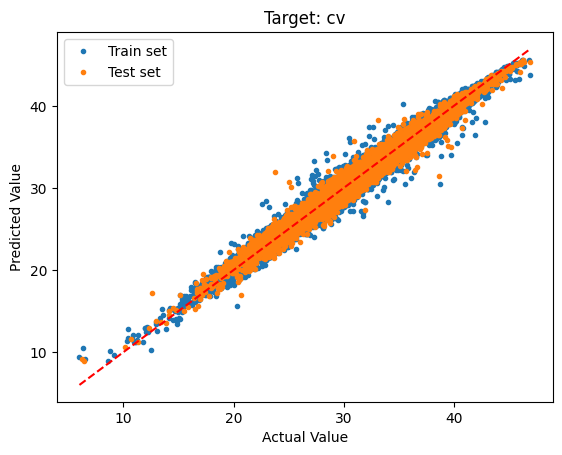

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018882 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5152
[LightGBM] [Info] Number of data points in the train set: 107010, number of used features: 41
[LightGBM] [Info] Start training from score -1751.332747


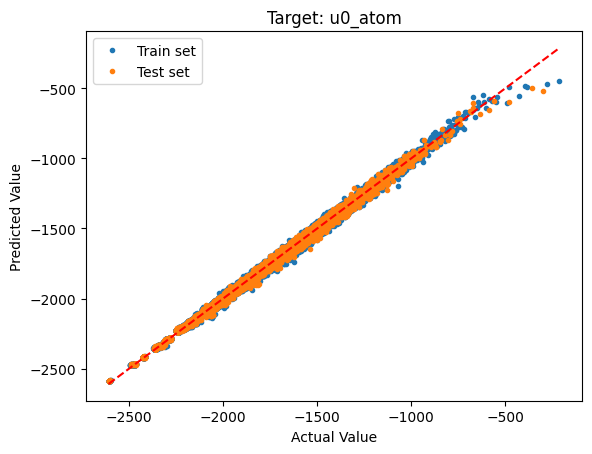

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.071302 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5152
[LightGBM] [Info] Number of data points in the train set: 107010, number of used features: 41
[LightGBM] [Info] Start training from score -1762.005919


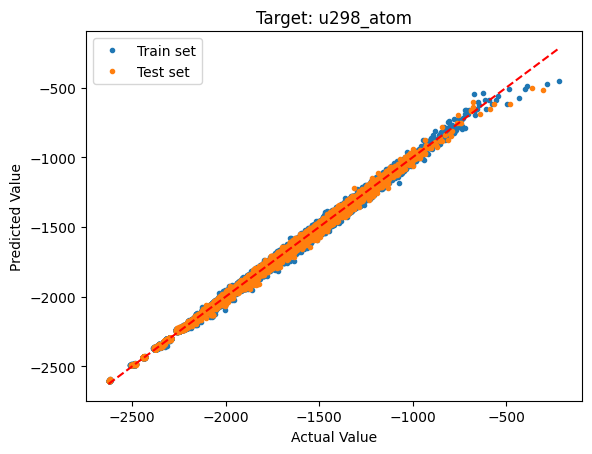

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018194 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5152
[LightGBM] [Info] Number of data points in the train set: 107010, number of used features: 41
[LightGBM] [Info] Start training from score -1772.074993


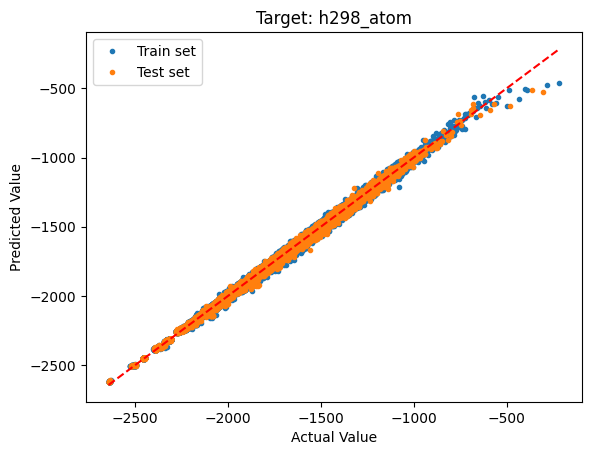

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5152
[LightGBM] [Info] Number of data points in the train set: 107010, number of used features: 41
[LightGBM] [Info] Start training from score -1629.872590


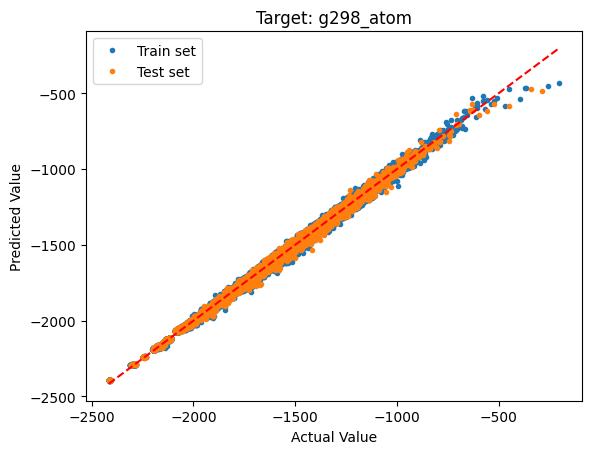

In [78]:
for t in targets:
  train_X = train[property_names]
  train_y = train[t]
  test_X = test[property_names]
  test_y = test[t]

  lgbm = LGBMRegressor()
  lgbm.fit(train_X, train_y)

  test_pred = lgbm.predict(test_X)
  train_pred = lgbm.predict(train_X)

  plt.plot(train_y, train_pred,'.',label='Train set')
  plt.plot(test_y, test_pred,'.',label='Test set')
  # to get a diagonal line
  diagonal_line =np.linspace(np.min(train_y),np.max(train_y),1000)
  plt.plot(diagonal_line,diagonal_line, color='red', linestyle='--')
  # plt.axline([0, 0], slope=1, color='red', linestyle='--')
  plt.legend()
  plt.ylabel("Predicted Value")
  plt.xlabel("Actual Value")
  plt.title(f"Target: {t:s}")
  plt.show()